# GAMS

## 1. Data Ingestion
## 2. Data Cleaning and Preprocessing
## 3. Exploratory Data Analysis
## 4. Feature Engineering
## 5. Machine Learning Model
## 6. Played-Game Recommendations

Use platform_mode='any' for cross-platform results or platform_mode='same' to restrict results to the played or selected platform.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [18]:
data = pd.read_csv('vgsales.csv')
data.columns = data.columns.str.strip()

required_columns = [
    'Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher',
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'
]
missing_columns = sorted(set(required_columns) - set(data.columns))
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

print(f'Loaded {len(data):,} rows and {data.shape[1]} columns.')
print(data.dtypes)

Loaded 16,598 rows and 11 columns.
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [19]:
categorical_columns = ['Name', 'Platform', 'Genre', 'Publisher']
numeric_columns = [
    'Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales',
    'Other_Sales', 'Global_Sales'
]
sales_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
missing_tokens = {'', 'n/a', 'na', 'null', 'none', 'unknown'}
missing_before = data.isna().sum()

for column in categorical_columns:
    data[column] = data[column].map(lambda value: value.strip() if isinstance(value, str) else value)
    data[column] = data[column].map(
        lambda value: pd.NA if isinstance(value, str) and value.lower() in missing_tokens else value
    )

for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors='coerce')

rows_before = len(data)
duplicate_rows = int(data.duplicated().sum())
data = data.drop_duplicates().copy()
invalid_sales = data[sales_columns].lt(0).any(axis=1)
invalid_sales_rows = int(invalid_sales.sum())
data = data.loc[~invalid_sales].dropna(subset=['Name', 'Global_Sales']).copy()

data['Year'] = data['Year'].round().astype('Int64')
data['Rank'] = data['Rank'].round().astype('Int64')
for column in ['Platform', 'Genre', 'Publisher']:
    data[column] = data[column].fillna('Unknown').astype('string')
data['Name'] = data['Name'].astype('string')
data['Year_Missing'] = data['Year'].isna()
data = data.reset_index(drop=True)

platform_groups = {
    value: 'PS' for value in ['PS', 'PS2', 'PS3', 'PS4', 'PS5', 'PSV', 'PSP']
}
platform_groups.update({value: 'XBOX' for value in ['X360', 'XOne', 'XBOX', 'XS', 'XB']})
platform_groups.update({value: 'Nintendo' for value in ['Wii', 'WiiU', 'DS', '3DS', 'Switch', 'GBA', 'GC', 'N64', 'SNES', 'NES', 'GB', 'GBC']})
platform_groups.update({value: 'Sega' for value in ['GEN', 'SCD', 'SAT', 'DC', 'GG']})
platform_groups.update({value: 'Atari' for value in ['2600', '5200', '7800', 'Lynx', 'Jaguar']})
platform_groups.update({value: 'Others' for value in ['NeoGeo', 'TG16', '3DO', 'WS', 'VB', 'PCFX', 'NG']})
data['Platform'] = data['Platform'].replace(platform_groups)

print(f'Rows retained: {len(data):,} / {rows_before:,}')
print(f'Duplicate rows removed: {duplicate_rows}')
print(f'Invalid-sales rows removed: {invalid_sales_rows}')
print(data.isna().sum())

Rows retained: 16,598 / 16,598
Duplicate rows removed: 0
Invalid-sales rows removed: 0
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher         0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
Year_Missing      0
dtype: int64


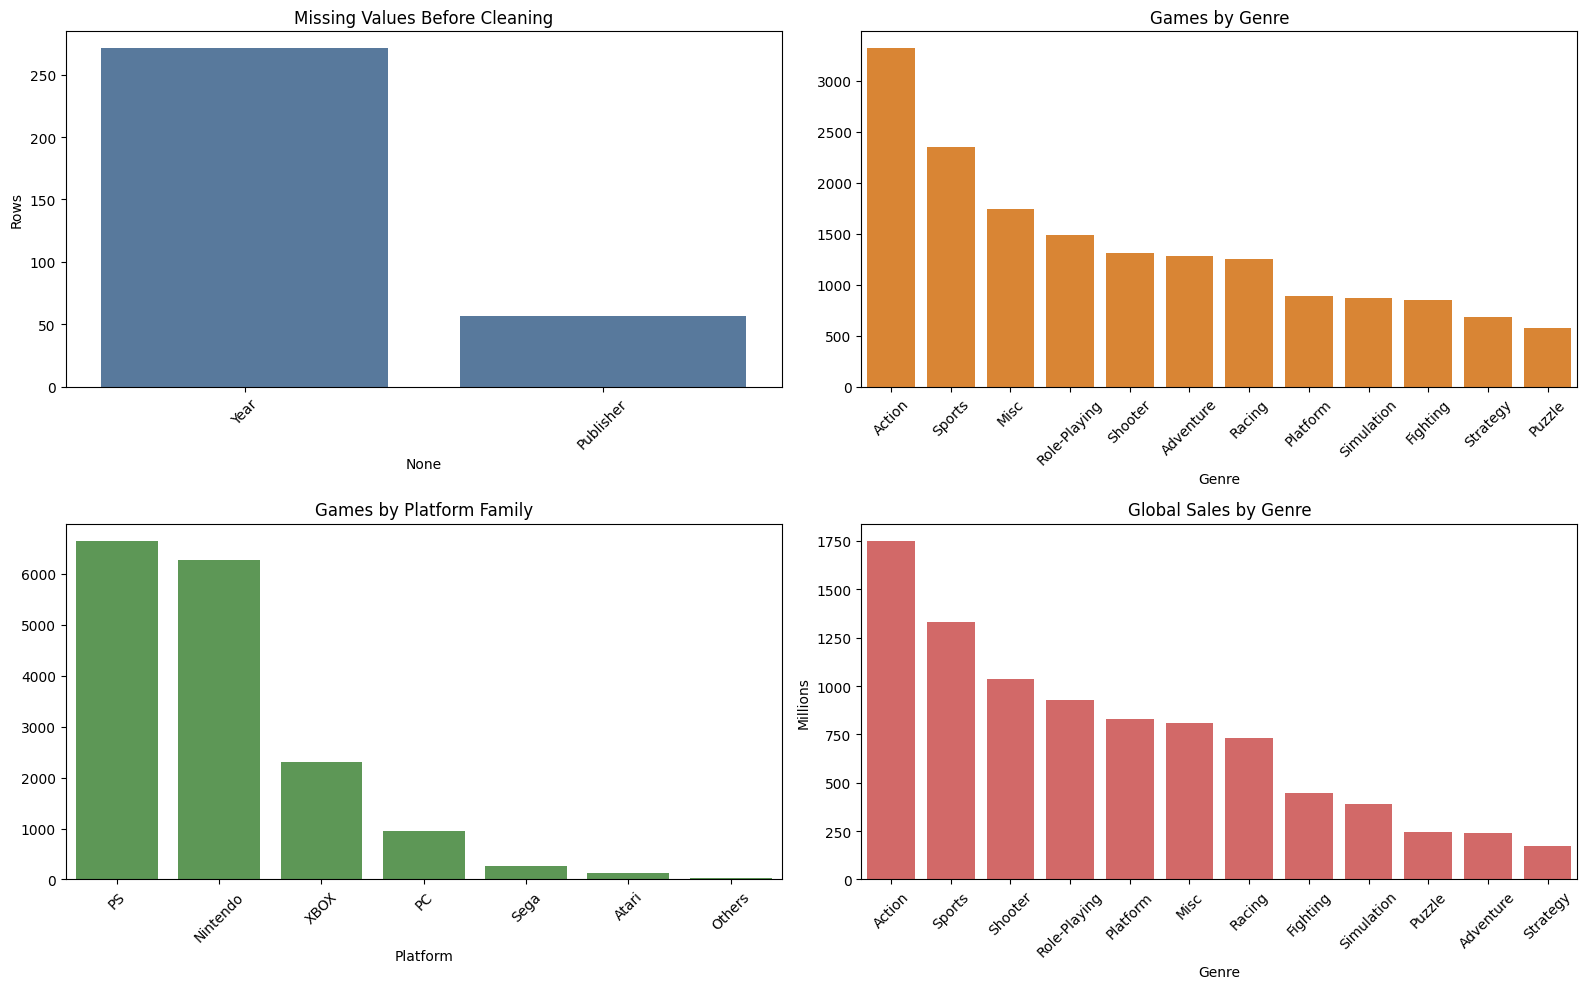

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

missing = missing_before[missing_before > 0].sort_values(ascending=False)
sns.barplot(x=missing.index, y=missing.values, color='#4C78A8', ax=axes[0, 0])
axes[0, 0].set_title('Missing Values Before Cleaning')
axes[0, 0].set_ylabel('Rows')
axes[0, 0].tick_params(axis='x', rotation=45)

genre_counts = data['Genre'].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, color='#F58518', ax=axes[0, 1])
axes[0, 1].set_title('Games by Genre')
axes[0, 1].tick_params(axis='x', rotation=45)

platform_counts = data['Platform'].value_counts()
sns.barplot(x=platform_counts.index, y=platform_counts.values, color='#54A24B', ax=axes[1, 0])
axes[1, 0].set_title('Games by Platform Family')
axes[1, 0].tick_params(axis='x', rotation=45)

sales_by_genre = data.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_genre.index, y=sales_by_genre.values, color='#E45756', ax=axes[1, 1])
axes[1, 1].set_title('Global Sales by Genre')
axes[1, 1].set_ylabel('Millions')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [21]:
model_data = data.copy()
model_data['Year_For_Feature'] = model_data['Year'].fillna(model_data['Year'].median()).astype(int)
model_data['Release_Decade'] = (model_data['Year_For_Feature'] // 10 * 10).astype(str)
model_data['Log_Global_Sales'] = np.log1p(model_data['Global_Sales'])

model_features = ['Platform', 'Genre', 'Publisher', 'Year_For_Feature', 'Release_Decade']
categorical_features = ['Platform', 'Genre', 'Publisher', 'Release_Decade']
numeric_features = ['Year_For_Feature']
target = 'Global_Sales'

print(model_data[model_features + [target]].head())

   Platform         Genre Publisher  Year_For_Feature Release_Decade  \
0  Nintendo        Sports  Nintendo              2006           2000   
1  Nintendo      Platform  Nintendo              1985           1980   
2  Nintendo        Racing  Nintendo              2008           2000   
3  Nintendo        Sports  Nintendo              2009           2000   
4  Nintendo  Role-Playing  Nintendo              1996           1990   

   Global_Sales  
0         82.74  
1         40.24  
2         35.82  
3         33.00  
4         31.37  


## 5. Machine Learning Model

The model predicts log global sales from metadata. Sales columns and Rank are excluded from the inputs to avoid target leakage.

MAE: 0.474
RMSE: 1.992
R2: 0.056


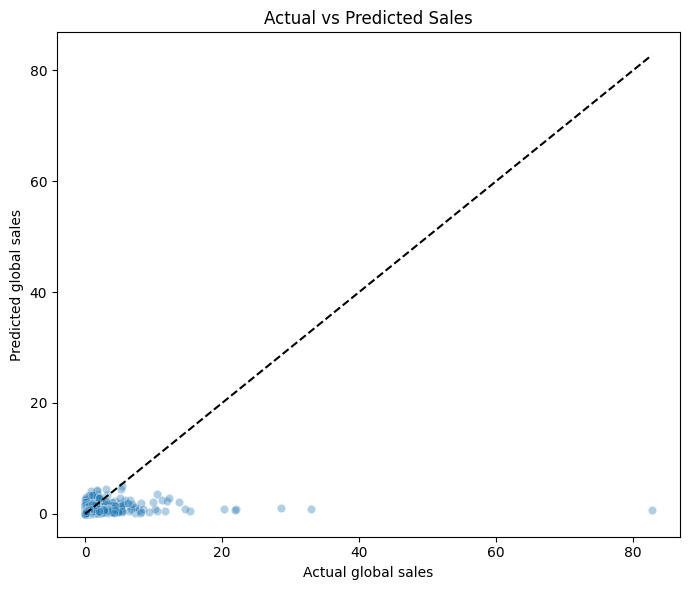

In [22]:
train_index, test_index = train_test_split(
    model_data.index, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

sales_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=250,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

X_train = model_data.loc[train_index, model_features]
X_test = model_data.loc[test_index, model_features]
y_train = model_data.loc[train_index, 'Log_Global_Sales']
y_test = model_data.loc[test_index, 'Global_Sales']

sales_model.fit(X_train, y_train)
predicted_sales = np.maximum(np.expm1(sales_model.predict(X_test)), 0)

mae = mean_absolute_error(y_test, predicted_sales)
rmse = np.sqrt(mean_squared_error(y_test, predicted_sales))
r2 = r2_score(y_test, predicted_sales)
print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R2: {r2:.3f}')

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=predicted_sales, alpha=0.35)
max_value = max(y_test.max(), predicted_sales.max())
plt.plot([0, max_value], [0, max_value], '--', color='black')
plt.xlabel('Actual global sales')
plt.ylabel('Predicted global sales')
plt.title('Actual vs Predicted Sales')
plt.tight_layout()
plt.show()

## 6. Model-Based Recommendations

In [23]:
def normalize_title(value):
    return ''.join(character.lower() for character in str(value) if character.isalnum() or character == ' ').strip()

title_aliases = {
    'gta san andreas': 'grand theft auto san andreas',
    'gta sa': 'grand theft auto san andreas'
}

platform_aliases = {
    'windows': 'pc', 'computer': 'pc', 'playstation': 'ps',
    'sony playstation': 'ps', 'ps1': 'ps', 'ps one': 'ps',
    'playstation 2': 'ps', 'playstation 3': 'ps', 'playstation 4': 'ps',
    'playstation 5': 'ps', 'xbox': 'xbox', 'xbox 360': 'xbox',
    'xbox one': 'xbox'
}

def normalize_platform(value):
    normalized = normalize_title(value)
    return platform_aliases.get(normalized, normalized)

def find_played_game(game_name, platform=None):
    query = normalize_title(game_name)
    query = title_aliases.get(query, query)
    matches = model_data[model_data['Name'].map(normalize_title) == query]
    if platform:
        platform_matches = matches[matches['Platform'].str.lower() == normalize_platform(platform)]
        if not platform_matches.empty:
            matches = platform_matches
    if matches.empty:
        raise ValueError('Played game was not found in the catalog. Try a fuller title.')
    return matches.iloc[0]

def recommend_from_played_game(game_name, played_platform=None, platform_mode='any', platform=None, n=10):
    seed = find_played_game(game_name, played_platform)
    if platform_mode not in {'any', 'same'}:
        raise ValueError("platform_mode must be 'any' or 'same'")

    candidates = model_data.copy()
    if platform_mode == 'same':
        selected_platform = normalize_platform(platform or played_platform)
        if not selected_platform:
            raise ValueError('Provide a platform when platform_mode is same.')
        candidates = candidates[candidates['Platform'].str.lower() == selected_platform]
    candidates = candidates[candidates['Name'] != seed['Name']].copy()
    if candidates.empty:
        return pd.DataFrame()

    candidates['Predicted_Global_Sales'] = np.maximum(
        np.expm1(sales_model.predict(candidates[model_features])), 0
    )
    candidates['Genre_Match'] = (candidates['Genre'] == seed['Genre']).astype(int)
    candidates['Publisher_Match'] = (candidates['Publisher'] == seed['Publisher']).astype(int)
    candidates['Decade_Match'] = (candidates['Release_Decade'] == seed['Release_Decade']).astype(int)
    candidates['Relatedness_Score'] = (
        0.50 * candidates['Genre_Match']
        + 0.30 * candidates['Publisher_Match']
        + 0.20 * candidates['Decade_Match']
    )
    sales_rank = candidates['Predicted_Global_Sales'].rank(pct=True)
    candidates['Recommendation_Score'] = (
        0.70 * candidates['Relatedness_Score'] + 0.30 * sales_rank
    )

    return (
        candidates.sort_values(
            ['Recommendation_Score', 'Predicted_Global_Sales'],
            ascending=False
        )
        .drop_duplicates('Name')
        .head(n)[[
            'Name', 'Platform', 'Genre', 'Publisher', 'Year',
            'Predicted_Global_Sales', 'Relatedness_Score', 'Recommendation_Score'
        ]]
        .reset_index(drop=True)
    )

recommend_from_played_game(
    game_name='GTA San Andreas',
    played_platform='PC',
    platform_mode='same',
    n=3
)

,Name,Platform,Genre,Publisher,Year,Predicted_Global_Sales,Relatedness_Score,Recommendation_Score
0,Mafia,PC,Action,Take-Two Interactive,2002,0.478279,1.0,0.967623
1,Grand Theft Auto III,PC,Action,Take-Two Interactive,2002,0.478279,1.0,0.967623
2,Grand Theft Auto: Vice City,PC,Action,Take-Two Interactive,2003,0.443229,1.0,0.962774


## Current Scope

The model learns expected sales from game metadata. The played game supplies the genre, publisher, and release period used for relevance, while the platform mode controls whether results can come from any platform or only a selected platform.

This is not a fully personalized recommender because the dataset has no user ratings, clicks, purchases, or play history. The next steps are baseline comparison, tuning, model persistence, and the FastAPI frontend/backend.